<a href="https://colab.research.google.com/github/EvnGgnn/TheGreenPixels/blob/Evan/Chlorophyll_Concentration_and_Shipping_Routes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Collection Period: January 2021 - Present

At this link we can obtain chlorophyll density data from NASA Satellites
https://neo.gsfc.nasa.gov/view.php?datasetId=MY1DMW_CHLORA&date=2025-11-01

In [31]:
import numpy as np
import pandas as pd
import datetime
import os
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
FILEPATH = 'https://neo.gsfc.nasa.gov/archive/geotiff.float/MY1DMW_CHLORA/'
extension_list = []
#Generate the url for the geotiffs
initial_date = datetime.datetime(2021, 1, 1, 0, 0, 0)
end_week_date = initial_date+datetime.timedelta(days=+7)
while end_week_date <= datetime.datetime(2025, 12, 26, 0, 0, 0):
  extension_list.append(f"AQUA_MODIS.{initial_date.year:04d}{initial_date.month:02d}{initial_date.day:02d}_{end_week_date.year:04d}{end_week_date.month:02d}{end_week_date.day:02d}.L3m.8D.CHL.chlor_a.4km.tif")
  initial_date = end_week_date+datetime.timedelta(days=+1)
  end_week_date = initial_date+datetime.timedelta(days=+7)
  if end_week_date.year > initial_date.year:
    end_week_date = datetime.datetime(initial_date.year, 12, 31, 0, 0, 0)
extension_list

['AQUA_MODIS.20210101_20210108.L3m.8D.CHL.chlor_a.4km.tif',
 'AQUA_MODIS.20210109_20210116.L3m.8D.CHL.chlor_a.4km.tif',
 'AQUA_MODIS.20210117_20210124.L3m.8D.CHL.chlor_a.4km.tif',
 'AQUA_MODIS.20210125_20210201.L3m.8D.CHL.chlor_a.4km.tif',
 'AQUA_MODIS.20210202_20210209.L3m.8D.CHL.chlor_a.4km.tif',
 'AQUA_MODIS.20210210_20210217.L3m.8D.CHL.chlor_a.4km.tif',
 'AQUA_MODIS.20210218_20210225.L3m.8D.CHL.chlor_a.4km.tif',
 'AQUA_MODIS.20210226_20210305.L3m.8D.CHL.chlor_a.4km.tif',
 'AQUA_MODIS.20210306_20210313.L3m.8D.CHL.chlor_a.4km.tif',
 'AQUA_MODIS.20210314_20210321.L3m.8D.CHL.chlor_a.4km.tif',
 'AQUA_MODIS.20210322_20210329.L3m.8D.CHL.chlor_a.4km.tif',
 'AQUA_MODIS.20210330_20210406.L3m.8D.CHL.chlor_a.4km.tif',
 'AQUA_MODIS.20210407_20210414.L3m.8D.CHL.chlor_a.4km.tif',
 'AQUA_MODIS.20210415_20210422.L3m.8D.CHL.chlor_a.4km.tif',
 'AQUA_MODIS.20210423_20210430.L3m.8D.CHL.chlor_a.4km.tif',
 'AQUA_MODIS.20210501_20210508.L3m.8D.CHL.chlor_a.4km.tif',
 'AQUA_MODIS.20210509_20210516.L3m.8D.CH

In [33]:
import requests
save_path = "/content/drive/MyDrive/chlorophyll_geotiff"
os.makedirs(save_path, exist_ok=True)
for extension in extension_list:
  print(extension)
  r = requests.get(FILEPATH+extension)
  collab_path = os.path.join(save_path, extension)

  with open(collab_path, "wb") as f:
        f.write(r.content)

AQUA_MODIS.20210101_20210108.L3m.8D.CHL.chlor_a.4km.tif


ConnectionError: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))

Dimensions: 3600 x 1800
Number of bands: 1
CRS: EPSG:4326
Transform: | 0.10, 0.00,-180.00|
| 0.00,-0.10, 90.00|
| 0.00, 0.00, 1.00|


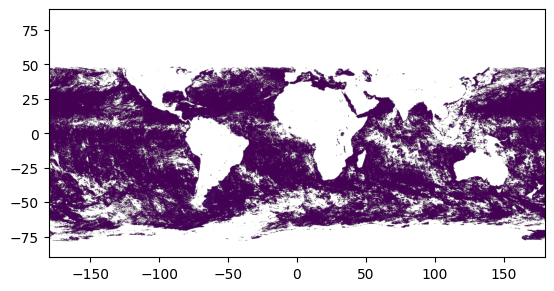

In [34]:
import rasterio
from rasterio.plot import show

with rasterio.open('/content/drive/MyDrive/chlorophyll_geotiff/AQUA_MODIS.20210101_20210108.L3m.8D.CHL.chlor_a.4km.tif') as src:
    # Read the data as a NumPy array
    array = src.read()

    # Print metadata
    print(f"Dimensions: {src.width} x {src.height}")
    print(f"Number of bands: {src.count}")
    print(f"CRS: {src.crs}")
    print(f"Transform: {src.transform}")

    # Visualize the first band
    show(src)